<a href="https://colab.research.google.com/github/faizakhoeruzzahra/UTS-Data-Mining/blob/main/2304020187_UTS_DATA_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

Library `pandas` dan `numpy` digunakan untuk pengolahan serta perhitungan data, sedangkan `matplotlib` dan `seaborn` digunakan untuk visualisasi data. `train_test_split` dan `cross_val_score` digunakan untuk membagi data serta melakukan validasi model. `accuracy_score`, `classification_report`, dan `confusion_matrix` digunakan untuk evaluasi hasil klasifikasi. `LabelEncoder` berfungsi mengubah data kategori menjadi numerik. Model klasifikasi yang digunakan yaitu `XGBClassifier`, sedangkan `SMOTE` digunakan untuk menangani data tidak seimbang. Terakhir, `joblib` digunakan untuk menyimpan model yang telah dilatih.


#1. Persiapan Data

In [22]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving data_testing.csv to data_testing (1).csv
Saving data_training.csv to data_training (1).csv


Kode di atas digunakan untuk mengunggah dataset. Output menunjukan data testing dan data training telah berhasil diunggah.

In [58]:
# Membaca dataset
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

Kode tersebut digunkan untuk membaca file data training dan data testing dengan format csv.

In [59]:
# Menampilkan 5 dataset teratas
print("Data Training")
display(df_train.head())
print("Data Testing")
display(df_test.head())

Data Training


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Data Testing


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


Kode di atas digunakan untuk menampilkan 5 dataset teratas. Output diatas menunjukan 5 tampilan dataset teratas pada data training dan data testing untuk mengetahui gambaran struktur dataset.

In [60]:
# Melihat informasi dataset
print("Info data training")
df_train.info()
print("\nInfo data testing")
df_test.info()

Info data training
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

Info data testing
<class 'pandas.core.frame.DataFrame'>
Ra

Kode di atas digunakan untuk melihat informasi dataset Berdasarkan output tersebut, data training terdiri dari 857 baris dan 13 kolom, sedangkan data testing terdiri dari 286 baris dan 12 kolom. Tipe data yang digunakan yaitu float64 dan int64, sehingga data sudah dalam bentuk numerik dan siap digunakan untuk proses klasifikasi.

In [61]:
# Melihat ukuran dataset
print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (857, 13)
Test shape : (286, 12)


Kode di atas digunakan untuk melihat ukuran dataset.  Output tersebut menunjukkan bahwa data training memiliki ukuran 857 baris dan 13 kolom, sedangkan data testing memiliki ukuran 286 baris dan 12 kolom. Perbedaan jumlah kolom terjadi karena data training masih memiliki kolom target quality, sedangkan data testing tidak memiliki kolom target.

#2. Pembersihan Data

In [62]:
# Mengecek missing value
print("Missing value data training:")
print(df_train.isnull().sum())

print("\nMissing value data testing:")
print(df_test.isnull().sum())

Missing value data training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing value data testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Kode tersebut digunakan untuk mengecek missing value pada data training dan data testing. Berdasarkan output diatas menunjukkan data bersih tidak terdapat missing value baik pada data training dan data testing.

In [63]:
# Mengecek duplikat data
print("Jumlah duplikat training:",
      df_train.duplicated().sum())

print("Jumlah duplikat testing:",
      df_test.duplicated().sum())

Jumlah duplikat training: 0
Jumlah duplikat testing: 0


Kode di atas digunakan untuk mengecek duplikat data. Berdasarkan output diperoleh tidak ada duplikat data pada data training dan data testing.

#3. Pembuatan Model

In [64]:
# Menyimpan Id data testing
id_test = df_test["Id"]

print("5 Id pertama data testing")
print(id_test.head())

5 Id pertama data testing
0     222
1    1514
2     417
3     754
4     516
Name: Id, dtype: int64


Kode tersebut digunakan untuk menyimpan kolom `Id` dari data testing ke dalam variabel `id_test`. Tujuannya agar identitas setiap data testing tetap tersimpan dan dapat digunakan kembali saat menampilkan hasil prediksi. Output yang ditampilkan menunjukkan 5 data `Id` pertama pada data testing, yaitu 222, 1514, 417, 754, dan 516.


In [65]:
# Memisahkan fitur dan target
X = df_train.drop(
    ["Id", "quality"],
    axis=1)

y = df_train["quality"]

X_test = df_test.drop(
    "Id",
    axis=1)

Kode tersebut digunakan untuk memisahkan fitur dan target pada data training. Variabel `X` berisi data fitur dengan menghapus kolom `Id` dan `quality`, sedangkan `y` berisi target yang akan diprediksi yaitu kolom `quality`. Pada data testing, variabel `X_test` dibuat dengan menghapus kolom `Id` karena kolom tersebut tidak digunakan dalam proses prediksi.

In [66]:
# Feature engineering
X["acidity_ratio"] = (
    X["fixed acidity"] /
    X["volatile acidity"])

X_test["acidity_ratio"] = (
    X_test["fixed acidity"] /
    X_test["volatile acidity"])

Pada tahap feature engineering, dibuat fitur baru bernama `acidity_ratio` yang diperoleh dari hasil pembagian `fixed acidity` dengan `volatile acidity`. Penambahan fitur ini bertujuan untuk membantu model mengenali hubungan tingkat keasaman pada wine sehingga performa prediksi dapat menjadi lebih baik.


In [67]:
# Label encoding target
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Kelas asli:")
print(sorted(y.unique()))

print("Kelas hasil encoding:")
print(sorted(np.unique(y_encoded)))

Kelas asli:
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Kelas hasil encoding:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Kode tersebut digunakan untuk melakukan label encoding pada data target `quality`, yaitu mengubah kelas asli menjadi label numerik agar dapat diproses oleh model machine learning.


In [68]:
# SMOTE untuk menangani data tidak seimbang
smote = SMOTE(
    random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X,
    y_encoded)

print("Ukuran data setelah SMOTE:")
print(X_resampled.shape)

Ukuran data setelah SMOTE:
(2172, 12)


Kode tersebut digunakan untuk menerapkan SMOTE dalam menangani data yang tidak seimbang dengan menambahkan data sintetis pada kelas minoritas. Hasil output menunjukkan ukuran data setelah SMOTE menjadi 2172 baris dan 12 kolom.


In [69]:
# Membagi data training dan validasi
X_train, X_valid, y_train, y_valid = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled)

Kode tersebut digunakan untuk membagi data hasil SMOTE menjadi data training dan data validasi. Sebanyak 80% data digunakan untuk training dan 20% untuk validasi, sedangkan `stratify` digunakan agar proporsi tiap kelas tetap seimbang.


In [70]:
# Membuat model XGBoost
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=10,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='multi:softmax',
    num_class=6,
    random_state=42)

Kode tersebut digunakan untuk membangun model klasifikasi menggunakan algoritma XGBoost dengan pengaturan parameter tertentu, seperti jumlah pohon (`n_estimators`), kecepatan pembelajaran (`learning_rate`), dan kedalaman pohon (`max_depth`) agar model dapat menghasilkan prediksi yang lebih optimal.

In [75]:
# Melatih model
model.fit(
    X_train,
    y_train)

print("Model XGBoost siap")

Model XGBoost siap


Kode tersebut digunakan untuk melatih model XGBoost menggunakan data training yang telah disiapkan. Output “Model XGBoost siap” menunjukkan bahwa proses pelatihan model berhasil dilakukan.


In [76]:
# Prediksi data validasi
y_pred = model.predict(X_valid)

Kode tersebut digunakan untuk melakukan prediksi pada data validasi menggunakan model XGBoost yang telah dilatih, sehingga menghasilkan nilai prediksi yang disimpan pada variabel `y_pred`.


In [77]:
# Menghitung akurasi
akurasi = accuracy_score(
    y_valid,
    y_pred)

print("Akurasi model XGBoost:",
      akurasi)

print("Akurasi dalam persen:",
      round(akurasi * 100, 2),
      "%")

Akurasi model XGBoost: 0.8528735632183908
Akurasi dalam persen: 85.29 %


Kode tersebut digunakan untuk menghitung tingkat akurasi model XGBoost dengan membandingkan hasil prediksi (`y_pred`) dan data sebenarnya (`y_valid`). Hasil output menunjukkan bahwa model memperoleh akurasi sebesar 0.8528 atau 85.29%, yang berarti model mampu melakukan prediksi dengan cukup baik.


In [45]:
# Cross validation
cv_score = cross_val_score(
    model,
    X_resampled,
    y_resampled,
    cv=5)

print("Rata-rata cross validation:",
      round(cv_score.mean() * 100, 2),
      "%")

Rata-rata cross validation: 84.99 %


Kode tersebut digunakan untuk melakukan cross validation sebanyak 5 kali guna mengukur kestabilan performa model XGBoost. Hasil output menunjukkan rata-rata akurasi cross validation sebesar 84.99%, yang menandakan model memiliki performa yang  baik dan stabil.


###Evaluasi Model

In [46]:
# Classification report
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       0.92      0.97      0.95        72
           2       0.75      0.68      0.71        73
           3       0.62      0.55      0.58        73
           4       0.85      0.92      0.88        73
           5       1.00      1.00      1.00        72

    accuracy                           0.85       435
   macro avg       0.85      0.85      0.85       435
weighted avg       0.85      0.85      0.85       435



Kode tersebut digunakan untuk menampilkan **classification report** yang berisi evaluasi performa model pada setiap kelas, yaitu precision, recall, f1-score, dan jumlah data (support). Hasil output menunjukkan bahwa model memiliki akurasi keseluruhan sekitar 85%, dengan performa terbaik pada kelas 0, 1, dan 5, sedangkan kelas 2 dan 3 memiliki nilai yang lebih rendah dibanding kelas lainnya.


###Confusion Matrix

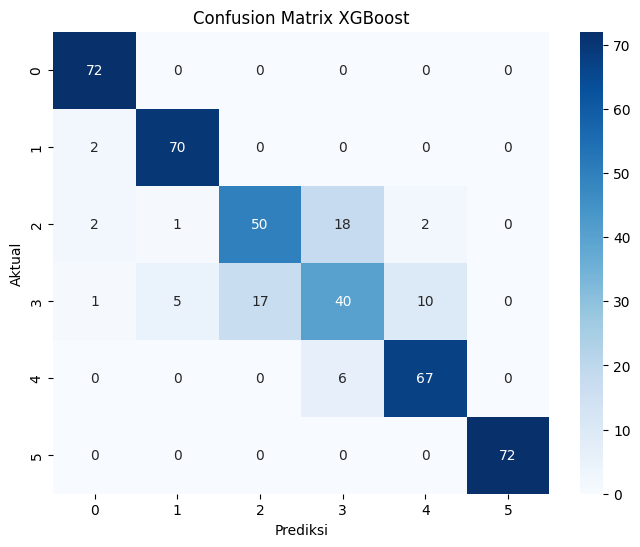

In [49]:
# Confusion matrix
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix XGBoost")

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.show()

Kode di atas digunakan untuk menampilkan confusion matrix dari model XGBoost dengan input berupa data aktual (`y_valid`) dan data hasil prediksi (`y_pred`). Fungsi `confusion_matrix()` digunakan untuk menghitung hasil klasifikasi, kemudian divisualisasikan menggunakan `sns.heatmap()` dari Seaborn dengan warna biru, judul grafik, serta label sumbu “Prediksi” dan “Aktual”. Output yang dihasilkan berupa confusion matrix yang menunjukkan jumlah prediksi benar pada diagonal utama dan kesalahan prediksi pada bagian luar diagonal, sehingga dapat digunakan untuk mengevaluasi performa model klasifikasi.


                   Fitur  Importance
1       volatile acidity    0.193761
10               alcohol    0.121516
9              sulphates    0.105564
6   total sulfur dioxide    0.085118
4              chlorides    0.076663
11         acidity_ratio    0.068058
5    free sulfur dioxide    0.063830
2            citric acid    0.060091
7                density    0.059533
0          fixed acidity    0.056058
8                     pH    0.055385
3         residual sugar    0.054424


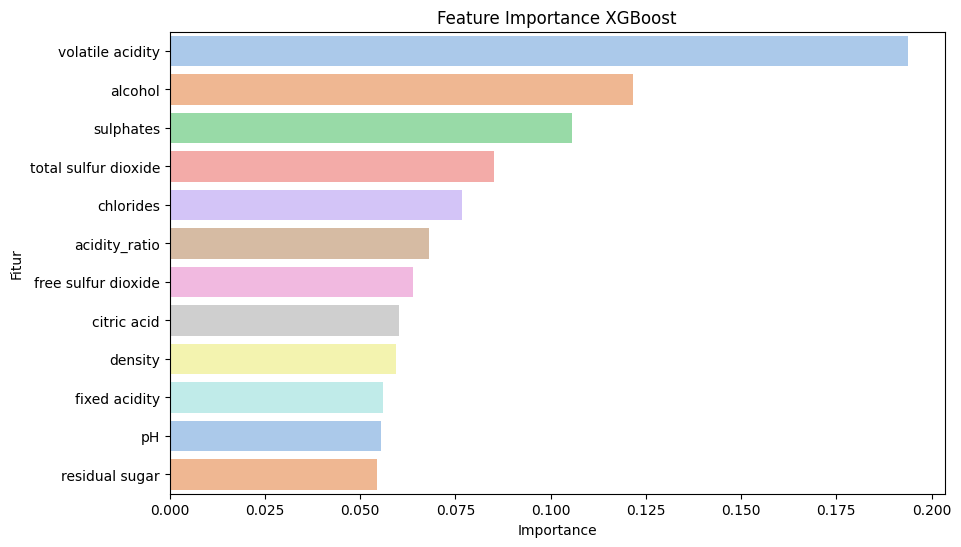

In [51]:
# Feature importance
importance = model.feature_importances_

fitur = pd.DataFrame({"Fitur": X.columns, "Importance": importance})

fitur = fitur.sort_values(by="Importance", ascending=False)

print(fitur)

plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Fitur", data=fitur, palette='pastel')

plt.title("Feature Importance XGBoost")

plt.show()

Kode di atas digunakan untuk menampilkan feature importance pada model XGBoost dengan input berupa nilai importance (`model.feature_importances_`) dan nama fitur (`X.columns`). Output yang dihasilkan berupa tabel dan grafik batang menggunakan Seaborn yang menunjukkan tingkat pengaruh setiap fitur terhadap hasil prediksi model.


#4. Prediksi Data Uji

In [52]:
# Prediksi data testing
prediksi_test = model.predict(X_test)

prediksi_test_asli = (label_encoder.inverse_transform(prediksi_test))

print("10 hasil prediksi pertama")
print(prediksi_test_asli[:10])

10 hasil prediksi pertama
[5 4 5 5 5 6 5 5 6 5]


Kode tersebut digunakan untuk melakukan prediksi pada data testing menggunakan model XGBoost, kemudian hasil prediksi yang masih dalam bentuk angka dikembalikan ke bentuk kelas asli menggunakan `inverse_transform` dari `LabelEncoder`. Output menunjukkan 10 hasil prediksi pertama kualitas wine, yaitu [5, 4, 5, 5, 5, 6, 5, 5, 6, 5].


In [53]:
# Membuat dataframe hasil prediksi
hasil_prediksi = pd.DataFrame({"Id": id_test, "Quality": prediksi_test_asli})
display(hasil_prediksi.head())

,Id,Quality
0,222,5
1,1514,4
2,417,5
3,754,5
4,516,5


kode tersebut digunakan untuk menampilkan hasil prediksi kualitas data uji dalam bentuk tabel dengan input berupa `id_test` sebagai identitas data dan `prediksi_test_asli` sebagai hasil prediksi kualitas dari model XGBoost. Output yang dihasilkan berupa dataframe yang berisi kolom `Id` dan `Quality`, sehingga hasil prediksi setiap data dapat ditampilkan dengan jelas.


In [54]:
# Menyimpan file CSV
hasil_prediksi.to_csv("hasilprediksi_187.csv", index=False)
print("File hasil prediksi berhasil disimpan")

File hasil prediksi berhasil disimpan


Kode tersebut digunakan untuk menyimpan hasil prediksi ke dalam file berformat CSV dengan nama **“hasilprediksi_187.csv”**. Output “File hasil prediksi berhasil disimpan” menunjukkan bahwa proses penyimpanan data berhasil dilakukan.


In [78]:
# Mengunduh file CSV
files.download("hasilprediksi_187.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Kode tersebut digunakan untuk mengunduh file **“hasilprediksi_187.csv”** ke perangkat, sehingga hasil prediksi yang sudah disimpan dalam bentuk csv dapat langsung diambil dan digunakan di luar notebook.


In [56]:
# Menyimpan model
joblib.dump(model, "model_xgboost_wine.pkl")
print("Model berhasil disimpan")

Model berhasil disimpan


Kode tersebut digunakan untuk menyimpan model XGBoost yang sudah dilatih ke dalam file berformat `.pkl` menggunakan `joblib`, dengan nama **"model_xgboost_wine.pkl"**, sehingga model dapat digunakan kembali tanpa perlu training ulang. Output “Model berhasil disimpan” menunjukkan proses penyimpanan model telah berhasil dilakukan.


In [57]:
print("\nKESIMPULAN")
print("1. Dataset berhasil diproses")
print("2. Tidak terdapat missing value")
print("3. Tidak terdapat data duplikat")
print("4. SMOTE berhasil menyeimbangkan data")
print("5. Feature engineering berhasil dilakukan")
print("6. Model XGBoost berhasil dilatih")
print("7. Akurasi model XGBoost =", round(akurasi * 100, 2), "%")
print("8. Hasil prediksi berhasil disimpan")


KESIMPULAN
1. Dataset berhasil diproses
2. Tidak terdapat missing value
3. Tidak terdapat data duplikat
4. SMOTE berhasil menyeimbangkan data
5. Feature engineering berhasil dilakukan
6. Model XGBoost berhasil dilatih
7. Akurasi model XGBoost = 85.29 %
8. Hasil prediksi berhasil disimpan
